# Corporación Favorita Grocery Sales Forecasting
## Statistical Models

## 1. Introduction

**Objective**

The goal of this notebook is to evaluate classical statistical models for forecasting daily unit_sales.

The dataset was prepared and cleaned in Notebook 01 (Data Preparation and EDA).
The time series is continuous and daily, covering the following periods:

- **Training period**: 2013-01-02 -> 2013-12-31
- **Test period**: 2014-01-01 -> 2014-03-31

The test period is kept fixed and is used for consistent out-of-sample comparison across models in this notebook.

### Modeling Strategy

Exploratory analysis indicates:

- Clear weekly seasonality  
- Relatively stable variance  
- No missing values (after imputation in Notebook 01) 
- Stationary behavior in levels (confirmed by the ADF test)

Based on these characteristics, the following models are considered:

- **Seasonal Naive (t-7)** — baseline benchmark  
- **ARIMA** — non-seasonal benchmark  
- **SARIMA** — seasonal ARIMA model (weekly period m = 7)  
- **SARIMAX** — SARIMA with calendar-based exogenous variables  
- **Exponential Smoothing (Holt-Winters)** — additive trend and weekly seasonality  

Models are compared using out-of-sample performance on the fixed test period (Jan-Mar 2014).

Residual diagnostics are performed only on the best-performing statistical model, in order to avoid redundancy and maintain focus on the final candidate.

**Evaluation Criteria**

Models are evaluated on the fixed test period using:

- **MAE** (Mean Absolute Error) - primary selection metric

- **RMSE** (Root Mean Squared Error)

- **sMAPE** (Symmetric Mean Absolute Percentage Error)


MAE is used as the primary selection metric, together with RMSE and sMAPE for additional insight.
The coefficient of determination (R²) is not included, as it is less informative for time series forecasting tasks and may be misleading in the presence of strong seasonality.

**MLflow Tracking**

The top statistical candidates (best-performing models) are registered in MLflow to enable structured comparison with machine learning models in Notebook 03.

This ensures structured experiment tracking and enables comparison with machine learning models developed in the subsequent notebook.

## 2. Setup and Load Cleaned Data

The cleaned dataset created in Notebook 01 is loaded below.  
The index is converted to a daily DateTimeIndex to ensure compatibility with statistical forecasting models.

Basic integrity checks are performed to confirm:
- correct date range
- continuous daily frequency
- no missing values
- no duplicate dates

### 2.1 Load Libraries

In [34]:
# Load Libraries

# Data Handling
# ----------------------------------------------------------
import pandas as pd
import numpy as np

# Visualization
# ----------------------------------------------------------
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Statistical Time Series Models
# ----------------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

import mlflow


### 2.2 Load Data and Integrity Checks

In [35]:
from pathlib import Path

# Notebook is in notebooks
BASE_DIR = Path().resolve().parent
DATA_PATH  = BASE_DIR / "data"

In [36]:
# MLflow setup
MLFLOW_PATH = BASE_DIR / "mlflow.db"

# Tracking URI points to the folder where MLflow stores runs
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_PATH}")

# Experiment groups runs for this project
mlflow.set_experiment("Favorita_Sales_Forecasting")

2026/03/01 15:54:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/01 15:54:25 INFO mlflow.store.db.utils: Updating database tables
2026/03/01 15:54:25 INFO mlflow.tracking.fluent: Experiment with name 'Favorita_Sales_Forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/mapi/Desktop/Masterschool_Data_Science/TimeSeries/corporacion_favorita/notebooks/mlruns/1', creation_time=1772376865376, experiment_id='1', last_update_time=1772376865376, lifecycle_stage='active', name='Favorita_Sales_Forecasting', tags={}, workspace='default'>

In [37]:
# Load Data
df = pd.read_csv(DATA_PATH / "timeseries_cleaned.csv")

# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Sort and set index
df = df.sort_values("date").set_index("date")

# Force daily frequency
df = df.asfreq("D")

# Integrity checks
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("Observations:", len(df))
print("Index frequency:", df.index.freq)
print("\nMissing values per column:\n", df.isna().sum())
print("\nDuplicate dates:", df.index.duplicated().sum())

df.head()

Date range: 2013-01-02 to 2014-03-31
Observations: 454
Index frequency: <Day>

Missing values per column:
 unit_sales         0
day_of_week        0
is_weekend         0
holiday_weekday    0
holiday_weekend    0
is_national        0
is_regional        0
is_local           0
dtype: int64

Duplicate dates: 0


,unit_sales,day_of_week,is_weekend,holiday_weekday,holiday_weekend,is_national,is_regional,is_local
date,,,,,,,,
2013-01-02,582.0,2,0,0,0,0,0,0
2013-01-03,310.0,3,0,0,0,0,0,0
2013-01-04,338.0,4,0,0,0,0,0,0
2013-01-05,654.0,5,1,0,1,1,0,0
2013-01-06,979.0,6,1,0,0,0,0,0


In [38]:
# Quick type check
print(df.index.dtype)

datetime64[ns]


### 2.3 Time Series Overview

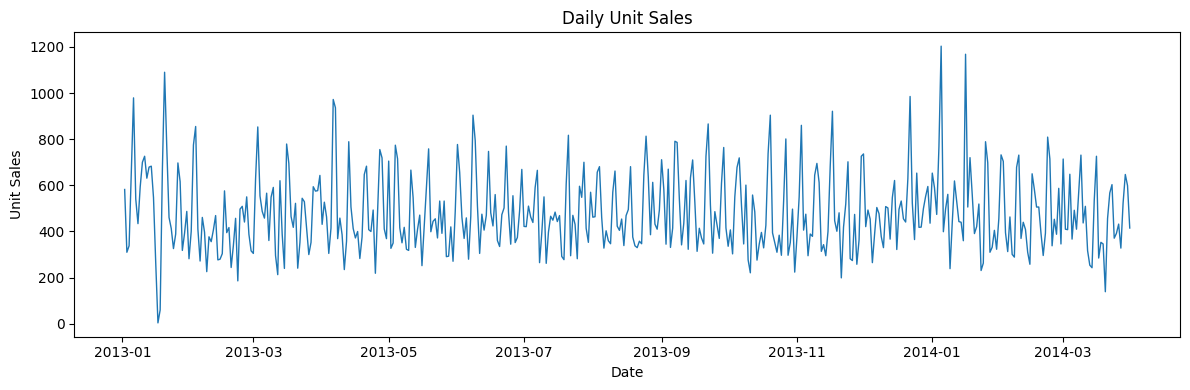

In [39]:
# A plot to verify the overall shape of the series before modeling.
plt.figure(figsize=(12,4))
plt.plot(df["unit_sales"], linewidth=1)
plt.title("Daily Unit Sales")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.tight_layout()
plt.show()

### 2.4 Stationarity and Autocorrelation

In [40]:
# ADF Test for stationarity
adf_result = adfuller(df["unit_sales"].dropna())

print("ADF Statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))

ADF Statistic: -4.9109
p-value: 0.0


**Note**: The Augmented Dickey-Fuller test is used to assess whether the series contains a unit root.

ADF Statistic: -5.3438  
p-value: 0.0000  

Since the p-value is well below 0.05, the null hypothesis of a unit root is rejected.  
The series can therefore be considered stationary in levels.

Non-seasonal differencing (d = 0) is appropriate.

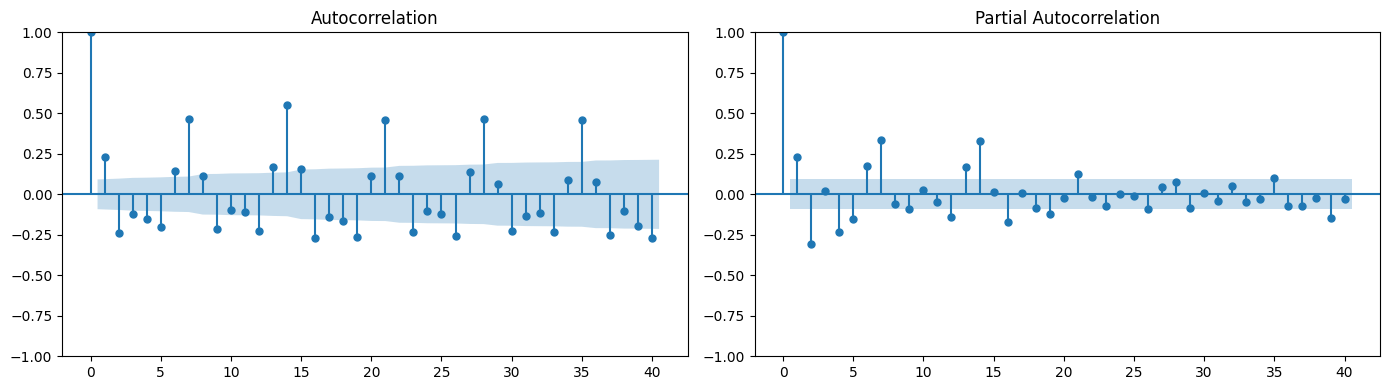

In [41]:
# ACF and PACF plots are examined to identify lag dependencies and seasonal structure.
fig, axes = plt.subplots(1, 2, figsize=(14,4))

plot_acf(df["unit_sales"], lags=40, ax=axes[0])
plot_pacf(df["unit_sales"], lags=40, ax=axes[1])

plt.tight_layout()
plt.show()

**Note**: The ACF and PACF plots provide insight into the temporal dependency structure.

The ACF shows strong and repeated spikes at multiples of lag 7 (7, 14, 21, 28, ...), clearly indicating a weekly seasonal pattern.

The PACF displays significant short-term dependence at the first few lags, suggesting the presence of a low-order autoregressive component.

Overall, the dependence structure appears stable and regular.

### 2.5 Modeling Implications

Based on the diagnostic analysis:

- The series is stationary in levels (d = 0).
- Strong weekly seasonality is present (seasonal period m = 7).
- Short-term autocorrelation suggests low-order AR and/or MA components.

For this reason:

- A non-seasonal ARIMA model is included as a benchmark.
- A SARIMA model with seasonal period 7 is expected to better capture the weekly structure.
- Exponential Smoothing with additive weekly seasonality is also considered as a competitive alternative.

### 2.6 Feature Engineering (for SARIMAX)

Although weekly seasonality is explicitly modeled via the seasonal component (m = 7), calendar-based exogenous variables are introduced to test whether additional explanatory power can be extracted from structured calendar effects.

Weekly seasonality is represented using cyclical encoding (`dow_sin`, `dow_cos`) to preserve the circular structure of the week (Sunday close to Monday).

Holiday interaction features are already available from Notebook 01.

In [42]:
# Cyclical encoding for weekly seasonality (Mon close to Sun)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

## 3. Train/Test Split

A fixed chronological split is used to evaluate model performance.

- **Training period:** 2013-01-02 -> 2013-12-31  
- **Test period:** 2014-01-01 -> 2014-03-31  

The split preserves the temporal order of the data.  
No shuffling is performed, as this would violate the time series structure.

The test set is held out and used exclusively for final model evaluation.

In [43]:
# Train/Test split
# Train: 2013 | Test: Jan–Mar 2014
train = df.loc["2013-01-02":"2013-12-31"].copy()
test  = df.loc["2014-01-01":"2014-03-31"].copy()

y_train = train["unit_sales"]
y_test  = test["unit_sales"]

print("Training observations:", len(train))
print("Test observations:", len(test))

Training observations: 364
Test observations: 90


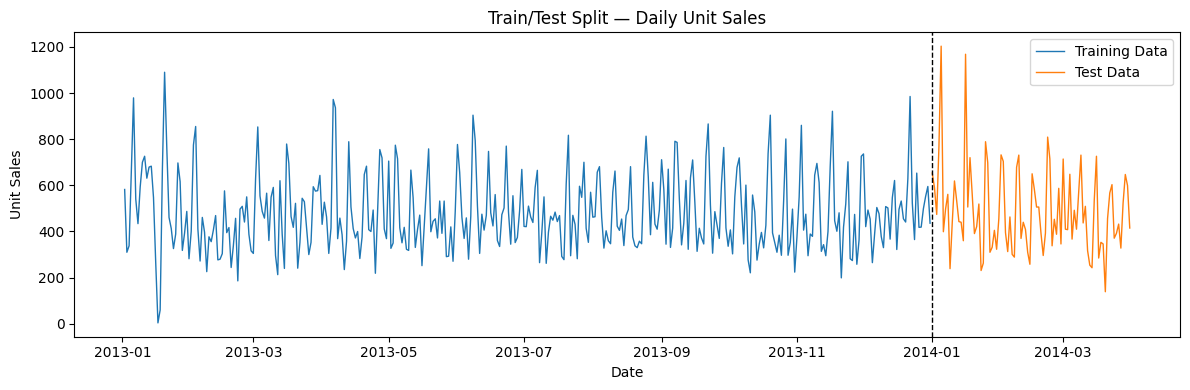

In [44]:
# Visual confirmation of the chronological train/test split
# This plot ensures:
# - no data leakage
# - correct temporal ordering
# - clear separation between training and evaluation periods

plt.figure(figsize=(12,4))

# Plot training data
plt.plot(train["unit_sales"], label="Training Data", linewidth=1)

# Plot test data
plt.plot(test["unit_sales"], label="Test Data", linewidth=1)

# Vertical line marking the split boundary
plt.axvline(pd.to_datetime("2014-01-01"),
            color="black", linestyle="--", linewidth=1)

plt.title("Train/Test Split — Daily Unit Sales")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()

plt.tight_layout()
plt.show()

## 4. Helpers

This section defines utility functions used consistently across all models:

- A standardized evaluation function (MAE, RMSE, sMAPE)
- A plotting function for visual comparison of forecasts vs. actual values
- A results container to store model performance in a structured format

In [45]:
# Helper function for evaluation
def evaluate_model(y_true, y_pred, model_name, family="Statistical"):

  """
  - MAE is used as the primary metric
  - RMSE highlights large errors (spikes/outliers)
  - sMAPE provides a stable percentage error metric (works with zeros)

  Compute forecast evaluation metrics and return a dictionary
  that can be appended to a results table.

  Note:
  - The index is aligned to avoid accidental misalignment between y_true and y_pred.
  - R² is not included because it is less informative for time series forecasting
  and can be misleading under strong seasonality.
  """

  # Ensure correct temporal alignment before computing metrics
  y_true, y_pred = y_true.align(y_pred, join="inner")

  # Core metrics
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))

  # Stable percentage metric handles zeros safely
  smape = 100 * np.mean(
      2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
  )

  # Print summary
  print(f"\n{model_name}")
  print(f"MAE   : {mae:.2f}")
  print(f"RMSE  : {rmse:.2f}")
  print(f"sMAPE : {smape:.2f}%")

  return {
      "Model": model_name,
      "MAE": mae,
      "RMSE": rmse,
      "sMAPE (%)": smape,
      "Family": family
  }


In [46]:
# Helper function for visualization
def plot_full_view(y_train, y_test, y_forecast, title):
  """
    Plot training data, test actuals, and the forecast on the same axis.
    This provides a full temporal view and highlights the train/test split.
  """
  plt.figure(figsize=(14,5))

  plt.plot(y_train.index, y_train, label="Train", linewidth=1)
  plt.plot(y_test.index, y_test, label="Test Actual", linewidth=1)
  plt.plot(y_forecast.index, y_forecast, label="Forecast", linestyle="--", linewidth=1.5)

  # Mark the boundary between train and test
  plt.axvline(y_train.index[-1], color="black", linestyle=":", linewidth=1, label="Train/Test Split")

  plt.title(title)
  plt.xlabel("Date")
  plt.ylabel("Unit Sales")
  plt.legend()
  plt.tight_layout()
  plt.show()

In [47]:
# Container to collect model performance metrics
results = []

In [48]:
# MLflow Artifact Helper: log forecast plot
# Logs actual vs forecast comparison as artifact
def log_forecast_plot(y_test, y_pred, model_name):
    """
    Logs a forecast vs actual plot as an MLflow artifact.

    Parameters
    ----------
    y_test : pd.Series  --> Actual test values
    y_pred : pd.Series  --> Model forecast aligned with test index
    model_name : str --> Used for plot title and artifact filename
    """

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(y_test.index, y_test.values, label="Actual", linewidth=1.5)
    ax.plot(y_pred.index, y_pred.values, label="Forecast", linewidth=1.5)

    ax.set_title(f"{model_name} — Forecast vs Actual (Test)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Unit Sales")
    ax.legend()

    plt.tight_layout()

    # Safe artifact name (no spaces)
    artifact_name = model_name.lower().replace(" ", "_")
    mlflow.log_figure(fig, f"plots/{artifact_name}_forecast.png")

    plt.close(fig)
    print(f"Logged artifact: plots/{artifact_name}_forecast.png")


**Note**:
- **MAE** measures the average absolute error in the original sales units (primary metric).
- **RMSE** penalizes large errors more strongly and is useful when spikes matter.
- **sMAPE** provides a percentage-based error measure and remains stable when actual values are near zero.

## 5. Baseline Model

A Seasonal Naive baseline is used as a reference model.

Given the strong weekly seasonality (m = 7), the baseline forecast predicts each day as the observed value from **7 days earlier**.

This baseline is expected to be difficult to beat unless a model captures weekly seasonality effectively.

In [49]:
# Baseline: Seasonal Naive (t-7)
# Each prediction is the value observed 7 days earlier.
# This is an appropriate benchmark when weekly seasonality is dominant.

# Build a "history" series to allow shifting across the train/test boundary
history = pd.concat([y_train, y_test])

# Forecast for the test period using values from 7 days earlier
y_pred_naive = history.shift(7).loc[y_test.index]

# Evaluate baseline performance on the test set
naive_metrics = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_naive,
    model_name="Seasonal Naive (t-7)",
    family="Statistical"
)

# Store results
results.append(naive_metrics)


Seasonal Naive (t-7)
MAE   : 131.53
RMSE  : 211.58
sMAPE : 26.52%


**Note**: The Seasonal Naive (t-7) model achieves:

- MAE: 131.53
- RMSE: 211.58
- sMAPE: 26.52%

The model benefits from the strong weekly seasonality present in the data.  
Since each prediction reuses the value from the previous week, it naturally captures recurring weekly patterns.

However, the magnitude of the errors indicates that the model does not account for short-term dynamics beyond simple repetition.

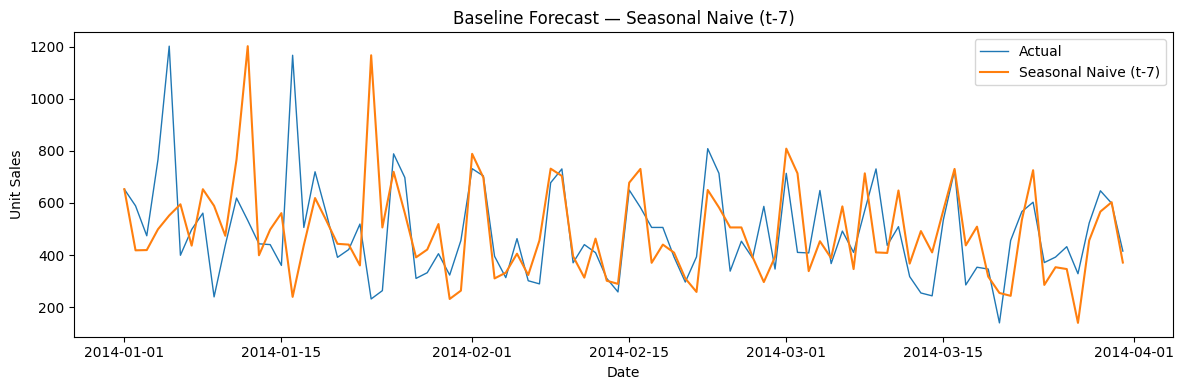

In [50]:
# Plot baseline forecast vs actual values (test period)
plt.figure(figsize=(12,4))
plt.plot(y_test.index, y_test, label="Actual", linewidth=1)
plt.plot(y_pred_naive.index, y_pred_naive, label="Seasonal Naive (t-7)", linewidth=1.5)
plt.title("Baseline Forecast — Seasonal Naive (t-7)")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.tight_layout()
plt.show()

**Note**: The forecast closely mirrors the weekly structure of the series, confirming that the model effectively reproduces recurring seasonal patterns.

However, noticeable deviations occur during sharp peaks and sudden changes in sales levels.  
The model simply replicates the previous week's value and therefore cannot anticipate unexpected variations.

This limitation explains the relatively high RMSE observed earlier.

## 6. ARIMA

An ARIMA model is fitted as a non-seasonal benchmark.

From the diagnostic analysis:

- The series is stationary in levels (ADF test: d = 0).
- The PACF suggests short-term autoregressive dependence.
- The ACF suggests short-term moving average structure.
- Strong seasonal spikes at lag 7 indicate weekly seasonality, which ARIMA does not explicitly model.

A low-order ARIMA model is therefore tested as a baseline non-seasonal alternative.

In [51]:
# ARIMA
arima_order= (1, 0, 1)

# Fit model on training data only
arima_model = ARIMA(y_train, order=(1, 0, 1))
arima_result = arima_model.fit()

# Forecast over test period
y_pred_arima = arima_result.forecast(steps=len(y_test))
y_pred_arima.index = y_test.index

# Evaluate performance
arima_metrics = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_arima,
    model_name="ARIMA(1,0,1)",
    family="Statistical"
)
# Store results
results.append(arima_metrics)


ARIMA(1,0,1)
MAE   : 142.02
RMSE  : 184.79
sMAPE : 29.12%


**Note**: The ARIMA(1,0,1) model achieves:

- MAE: 142.02
- RMSE: 184.79
- sMAPE: 29.12%

Despite modeling short-term autocorrelation, ARIMA does not outperform the Seasonal Naive baseline in terms of MAE or sMAPE.

This suggests that capturing weekly seasonality is more important for this dataset than modeling short-term autoregressive and moving average components alone.

The lower RMSE compared to the baseline indicates slightly reduced sensitivity to extreme deviations, but overall predictive accuracy remains inferior.

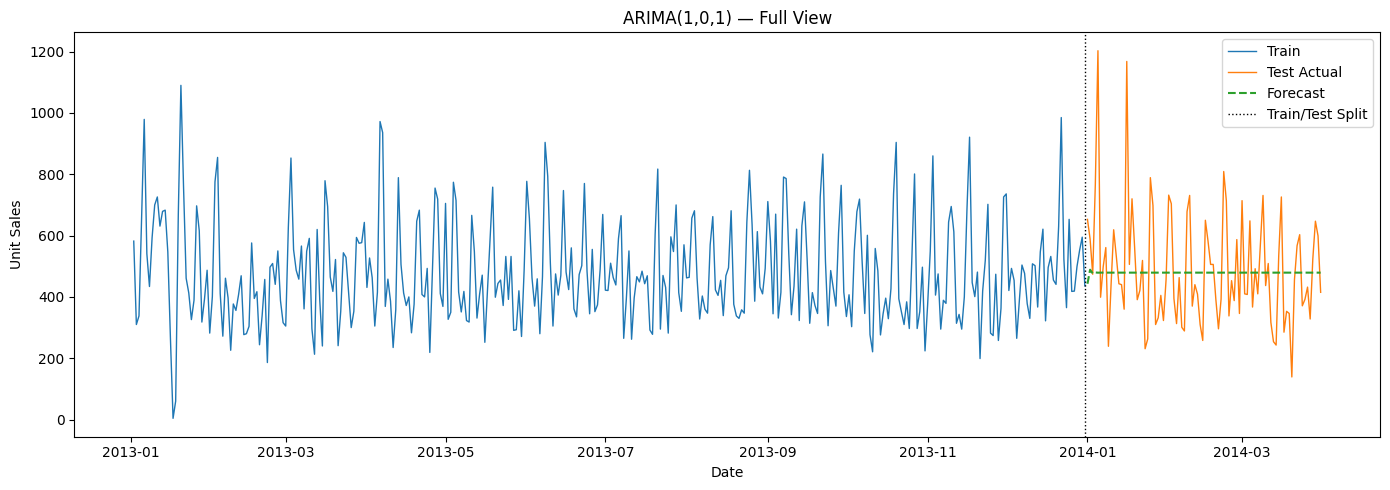

In [52]:
# Plot forecast vs actual (test period)
plot_full_view(y_train, y_test, y_pred_arima, title="ARIMA(1,0,1) — Full View")

**Note**: The ARIMA forecast quickly converges toward a relatively stable mean level.

Weekly fluctuations are not reproduced, and the model fails to capture the recurring seasonal peaks and troughs visible in the test data.

This behavior confirms that a non-seasonal ARIMA specification is insufficient for a series dominated by strong weekly seasonality.

## 7. SARIMA

The diagnostic analysis shows strong weekly seasonality with period **m = 7** (repeated spikes in the ACF at lags 7, 14, 21, ...).

A SARIMA model is therefore fitted to explicitly capture this seasonal structure.

The specification below combines:
- a low-order non-seasonal component to model short-term dependency  
- a seasonal component with weekly period (m = 7) and seasonal differencing (D = 1)

In [53]:
# SARIMA: fit on train only, evaluate on test
sarima_order = (1, 0, 1)
sarima_seasonal_order = (0, 1, 1, 7)   # (P, D, Q, m)

sarima_model = SARIMAX(
    y_train,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

# Forecast over the test horizon
y_pred_sarima = sarima_result.get_forecast(steps=len(y_test)).predicted_mean
y_pred_sarima = pd.Series(y_pred_sarima.values, index=y_test.index)

# Evaluate and store results
sarima_metrics = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_sarima,
    model_name="SARIMA(1,0,1)×(0,1,1,7)",
    family="Statistical"
)
# Store results
results.append(sarima_metrics)


SARIMA(1,0,1)×(0,1,1,7)
MAE   : 97.80
RMSE  : 145.23
sMAPE : 20.60%


**Note**: SARIMA significantly improves over both the Seasonal Naive baseline and the non-seasonal ARIMA model.

- MAE decreases from 131.53 (baseline) to 97.80.
- RMSE drops from 211.58 to 145.23.
- sMAPE improves from 26.52% to 20.60%.

This confirms that explicitly modeling weekly seasonality substantially enhances predictive performance.

The seasonal component (D=1, Q=1, m=7) effectively captures the recurring weekly structure that ARIMA failed to model.

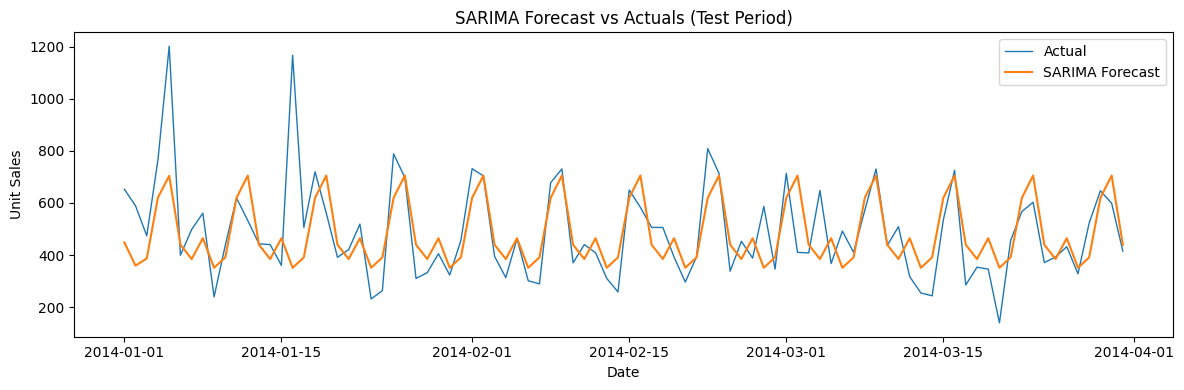

In [54]:
# Plot Test period forecast vs actual values
plt.figure(figsize=(12,4))
plt.plot(y_test.index, y_test, label="Actual", linewidth=1)
plt.plot(y_pred_sarima.index, y_pred_sarima, label="SARIMA Forecast", linewidth=1.5)
plt.title("SARIMA Forecast vs Actuals (Test Period)")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.tight_layout()
plt.show()

**Note**: The SARIMA forecast closely follows the weekly oscillation pattern observed in the actual sales.

Compared to ARIMA:
- The model no longer produces flat forecasts.
- Weekly peaks and troughs are clearly captured.
- Amplitude is slightly smoothed, but the seasonal structure is well represented.

Some extreme spikes are still under-predicted, which is expected for parametric statistical models.

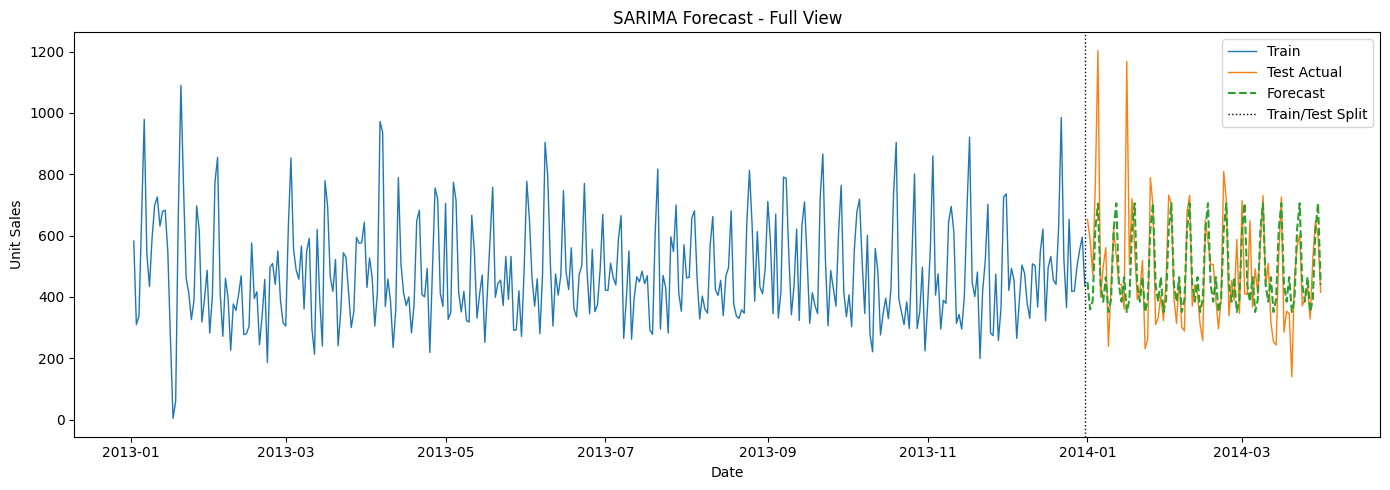

In [55]:
# Plot full view
plot_full_view(y_train, y_test, y_pred_sarima, "SARIMA Forecast - Full View")


**Note**: The forecast continues the seasonal structure learned during training and remains stable across the entire test horizon.

There is no visible structural break at the train/test boundary, suggesting that the model generalizes consistently.

Residual volatility remains, but the main weekly dynamics are accurately reproduced.

## 8. SARIMAX

SARIMA captures weekly seasonality well, but it cannot explicitly use calendar information.

To test whether holiday and weekend indicators add predictive value beyond the seasonal structure, a SARIMAX model is fitted using the same SARIMA specification and adding calendar-based exogenous variables.

In [56]:
# SARIMAX: SARIMA + exogenous calendar features
# Goal: test whether holiday/weekend effects improve forecasts

# Exogenous variables available for both train and test periods
# Weekly seasonality is represented via cyclical encoding (sin/cos)

exog_cols = [
    "dow_sin",
    "dow_cos",
    "holiday_weekday",
    "holiday_weekend",
    "is_national",
    "is_regional",
    "is_local"
]

X_train = train[exog_cols]
X_test  = test[exog_cols]

In [57]:
# SARIMAX: fit on train only, evaluate on test
# Model specification same as the best SARIMA so far
sarimax_order = (1, 0, 1)
sarimax_seasonal_order = (0, 1, 1, 7)

sarimax_model = SARIMAX(
    y_train,
    exog=X_train, # exogenous variables calendar effects
    order=sarimax_order, # non-seasonal (p,d,q)
    seasonal_order=sarimax_seasonal_order, # seasonal (P,D,Q,m)
    enforce_stationarity=False, # relax constraints for stability
    enforce_invertibility=False
)

# Fit with increased iterations to avoid convergence issues
sarimax_result = sarimax_model.fit(disp=False, maxiter=200)

# Generate out-of-sample forecast aligned with test index
y_pred_sarimax = sarimax_result.get_forecast(
    steps=len(y_test),
    exog=X_test
).predicted_mean

y_pred_sarimax = pd.Series(y_pred_sarimax.values, index=y_test.index)

# Evaluate forecast performance.
sarimax_metrics = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_sarimax,
    model_name=f"SARIMAX{sarimax_order}x{sarimax_seasonal_order} + calendar",
    family="Statistical"

)

# Store results
results.append(sarimax_metrics)



SARIMAX(1, 0, 1)x(0, 1, 1, 7) + calendar
MAE   : 96.66
RMSE  : 143.01
sMAPE : 20.38%


**Note**: The SARIMAX model achieves the following performance:

- MAE: 96.66  
- RMSE: 143.01  
- sMAPE: 20.38%

Compared to the seasonal SARIMA specification, the inclusion of calendar features provides a small but consistent improvement across all error metrics.

This suggests that while weekly seasonality explains most of the structure in the data, calendar effects add incremental explanatory power.

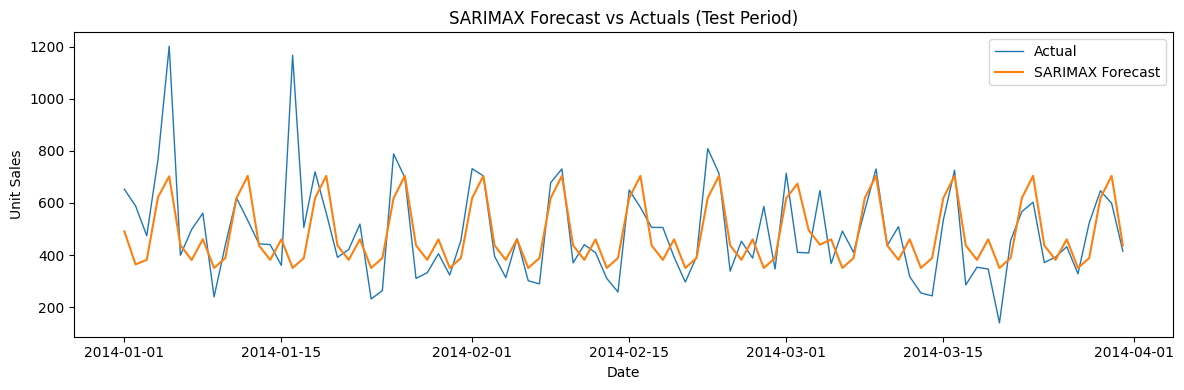

In [58]:
# Plot: SARIMAX forecast vs actual values test period
plt.figure(figsize=(12,4))
plt.plot(y_test.index, y_test, label="Actual", linewidth=1)
plt.plot(y_pred_sarimax.index, y_pred_sarimax, label="SARIMAX Forecast", linewidth=1.5)
plt.title("SARIMAX Forecast vs Actuals (Test Period)")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.tight_layout()
plt.show()

**Note**: The SARIMAX forecast closely overlaps with the SARIMA forecast.

While performance metrics show a small but consistent improvement when calendar features are included, no major structural differences are visually apparent in the forecast trajectory.

Weekly oscillations remain the dominant driver of predictions, and extreme spikes continue to be slightly under-predicted, consistent with the behavior observed in SARIMA.

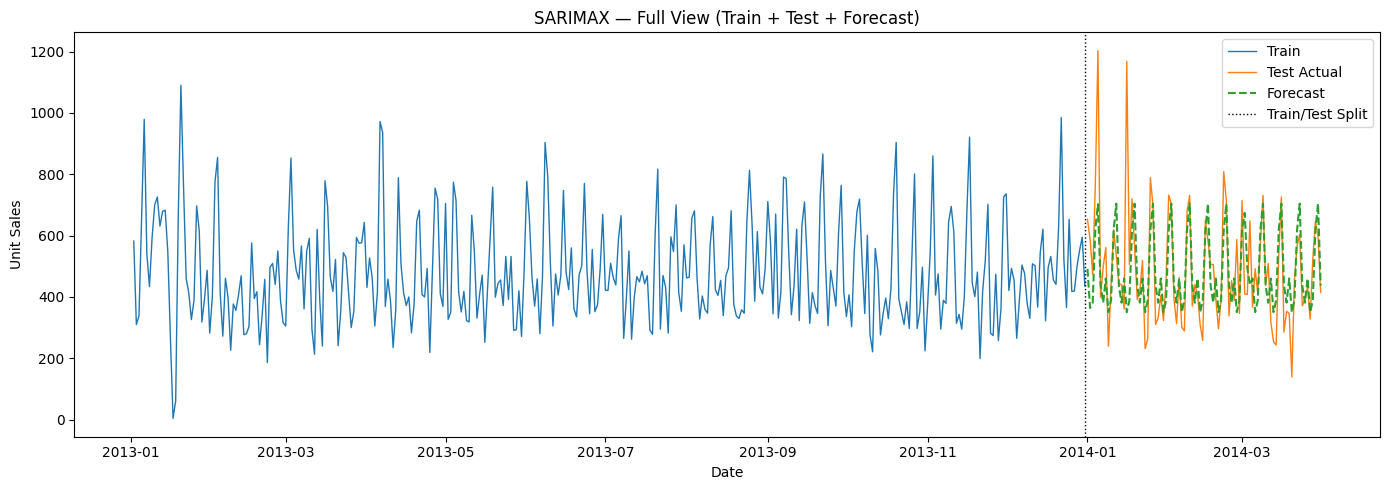

In [59]:
plot_full_view(y_train, y_test, y_pred_sarimax, title="SARIMAX — Full View (Train + Test + Forecast)")

**Note**: The forecast maintains stable weekly dynamics across the test horizon.

The addition of exogenous calendar variables does not materially alter the forecast trajectory compared to SARIMA.

This confirms that the seasonal component (m=7) already captures most systematic variation.

## 9. Exponential Smoothing

Exponential Smoothing provides a decomposition-based alternative to ARIMA-type models.

Given the exploratory analysis:
- No strong long-term trend,
- Clear weekly seasonality,
- Relatively stable seasonal amplitude,

An additive Holt-Winters specification with seasonal period m = 7 is used.

In [60]:
# Exponential Smoothing (Holt-Winters)
# Additive trend + additive weekly seasonality (m = 7)

es_model = ExponentialSmoothing(
    y_train,
    trend="add",        # mild additive trend
    seasonal="add",     # additive seasonality
    seasonal_periods=7  # weekly cycle
)

# Optimize smoothing parameters automatically
es_result = es_model.fit(optimized=True)

# Forecast over the full test horizon
y_pred_es = es_result.forecast(steps=len(y_test))
y_pred_es = pd.Series(y_pred_es.values, index=y_test.index)

# Evaluate
es_metrics = evaluate_model(
    y_true=y_test,
    y_pred=y_pred_es,
    model_name="Holt-Winters (Additive, m=7)",
    family="Statistical"
)

# Store results
results.append(es_metrics)


Holt-Winters (Additive, m=7)
MAE   : 97.44
RMSE  : 143.86
sMAPE : 20.57%


**Note**: Holt-Winters achieves performance comparable to SARIMA, with a small improvement in MAE and sMAPE.

- MAE: 97.44
- RMSE: 143.86
- sMAPE: 20.57%

This further confirms that capturing weekly seasonality is the dominant driver of performance in this dataset.

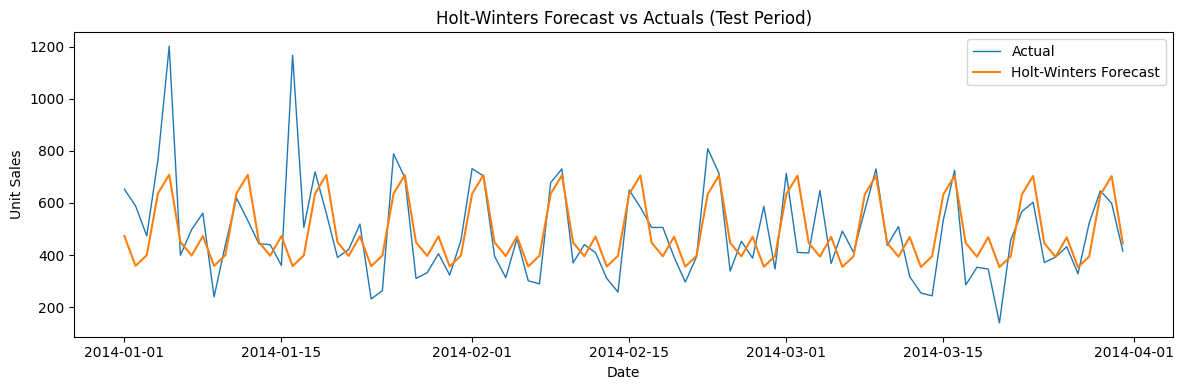

In [61]:
# Plot Exponential Smoothing forecast vs actual values test period
plt.figure(figsize=(12,4))
plt.plot(y_test.index, y_test, label="Actual", linewidth=1)
plt.plot(y_pred_es.index, y_pred_es, label="Holt-Winters Forecast", linewidth=1.5)
plt.title("Holt-Winters Forecast vs Actuals (Test Period)")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.tight_layout()
plt.show()

**Note**: The Holt-Winters forecast closely follows the weekly oscillatory pattern observed in the test period.

The model captures the recurring weekly structure effectively, producing forecasts that align well with average demand levels.

However, extreme peaks are slightly under-predicted, and sharp upward deviations are smoothed due to the additive exponential smoothing structure.

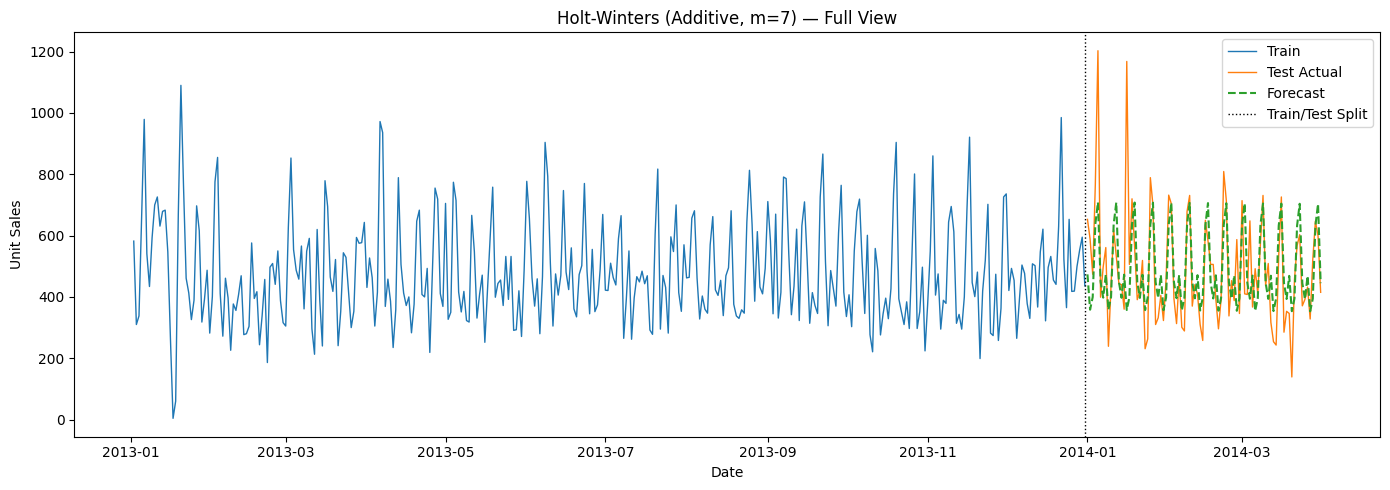

In [62]:
# Full view: train + test + forecast (Holt-Winters)
plot_full_view(
    y_train=y_train,
    y_test=y_test,
    y_forecast=y_pred_es,
    title="Holt-Winters (Additive, m=7) — Full View"
)

**Note**: In the full view, the Holt-Winters model maintains stable weekly seasonality across the forecast horizon.

The additive structure preserves consistent oscillations around the mean level, without introducing structural shifts at the train/test boundary.

While general demand dynamics are well captured, extreme spikes remain partially smoothed, reflecting the model's preference for stable seasonal patterns over abrupt irregular fluctuations.

## 10. Results Summary

In [63]:
# Display the results
results_df = pd.DataFrame(results).sort_values("MAE")
results_df

,Model,MAE,RMSE,sMAPE (%),Family
3,"SARIMAX(1, 0, 1)x(0, 1, 1, 7) + calendar",96.662971,143.014644,20.383486,Statistical
4,"Holt-Winters (Additive, m=7)",97.444854,143.857167,20.570011,Statistical
2,"SARIMA(1,0,1)×(0,1,1,7)",97.797957,145.229614,20.601163,Statistical
0,Seasonal Naive (t-7),131.533333,211.577987,26.523857,Statistical
1,"ARIMA(1,0,1)",142.022287,184.789636,29.123909,Statistical


### Model Comparison Summary

The table above shows that SARIMAX achieves the lowest MAE, RMSE, and sMAPE among the evaluated statistical models.

Although the improvement over Holt-Winters is moderate, it is consistent across all metrics.

SARIMA, SARIMAX and Holt-Winters are therefore logged to MLFlow.

In [64]:
# Log Sarimax to MLflow
with mlflow.start_run(run_name="SARIMAX_101_0117_calendar"):

    # Tags
    mlflow.set_tag("model_family", "statistical")
    mlflow.set_tag("notebook", "02")
    mlflow.set_tag("tuning_method", "manual")
    mlflow.set_tag("split", "train_2013_test_2014Q1")
    mlflow.set_tag("random_state", "3")
    mlflow.set_tag("features_fixed", "yes")

    # Params
    mlflow.log_param("model_type", "SARIMAX")
    mlflow.log_param("order", str(sarimax_order))
    mlflow.log_param("seasonal_order", str(sarimax_seasonal_order))
    mlflow.log_param("features", ",".join(exog_cols))

    # Metrics
    mlflow.log_metric("MAE", round(float(sarimax_metrics["MAE"]),2))
    mlflow.log_metric("RMSE", round(float(sarimax_metrics["RMSE"]),2))
    mlflow.log_metric("sMAPE", round(float(sarimax_metrics["sMAPE (%)"]),2))

    # Model artifact
    mlflow.statsmodels.log_model(sarimax_result, name="SARIMAX")
    # Plot artifact
    log_forecast_plot(y_test, y_pred_sarimax, "SARIMAX")

print("SARIMAX logged to MLflow.")

Logged artifact: plots/sarimax_forecast.png
SARIMAX logged to MLflow.


In [65]:
# Log Holt-Winters to MLflow
with mlflow.start_run(run_name="02_HoltWinters_additive"):

    # Tags
    mlflow.set_tag("model_family", "statistical")
    mlflow.set_tag("notebook", "02")
    mlflow.set_tag("tuning_method", "optimized")
    mlflow.set_tag("split", "train_2013_test_2014Q1")
    mlflow.set_tag("features_fixed", "yes")

    # Params
    mlflow.log_param("model_type", "HoltWinters")
    mlflow.log_param("trend", "additive")
    mlflow.log_param("seasonality_mode", "additive")
    mlflow.log_param("seasonal_periods", 7)
    mlflow.log_param("optimized", True)
    
    # Metrics
    mlflow.log_metric("MAE", round(float(es_metrics["MAE"]), 2))
    mlflow.log_metric("RMSE", round(float(es_metrics["RMSE"]), 2))
    mlflow.log_metric("sMAPE", round(float(es_metrics["sMAPE (%)"]), 2))
    
    # Model artifact
    mlflow.statsmodels.log_model(es_result, name="Holt-Winters")
    
    # Plot artifact
    log_forecast_plot(y_test, y_pred_es, "Holt-Winters")

print("Holt-Winters logged to MLflow.")

Logged artifact: plots/holt-winters_forecast.png
Holt-Winters logged to MLflow.


In [66]:
# Log Sarima to MLflow
with mlflow.start_run(run_name="02_SARIMA_101_0117"):

    mlflow.set_tag("model_family", "statistical")
    mlflow.set_tag("notebook", "02")
    mlflow.set_tag("tuning_method", "manual")
    mlflow.set_tag("split", "train_2013_test_2014Q1")
    mlflow.set_tag("features_fixed", "yes")

    mlflow.log_param("model_type", "SARIMA")
    mlflow.log_param("order", str(sarima_order))
    mlflow.log_param("seasonal_order", str(sarima_seasonal_order))

    mlflow.log_metric("MAE", round(float(sarima_metrics["MAE"]), 2))
    mlflow.log_metric("RMSE", round(float(sarima_metrics["RMSE"]), 2))
    mlflow.log_metric("sMAPE", round(float(sarima_metrics["sMAPE (%)"]), 2))

    # Model artifact
    mlflow.statsmodels.log_model(sarima_result, name="SARIMA")

    # Plot artifact
    log_forecast_plot(y_test, y_pred_sarima, "SARIMA")

print("SARIMA logged to MLflow.")

Logged artifact: plots/sarima_forecast.png
SARIMA logged to MLflow.


In [67]:
# Save the models in a csv file
results_df.to_csv(DATA_PATH / "results_statistical.csv", index=False)